<a href="https://colab.research.google.com/github/sjdyeet/concept_of_ai/blob/main/classification_2501589.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install & Import Libraries
!pip install -q scikit-learn==1.3.2 imbalanced-learn matplotlib pandas seaborn tensorflow==2.15.0 openpyxl joblib

import os, json, math, warnings
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (9,6)

# sklearn & imblearn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif, SelectFromModel
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# tensorflow / keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping




ERROR: Could not find a version that satisfies the requirement tensorflow==2.15.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0)
ERROR: No matching distribution found for tensorflow==2.15.0
Ready. TensorFlow: 2.19.0


In [ ]:
# Load Dataset & Save Provenance
DATA_PATH = "/content/sample_data/student_lifestyle.csv.xlsx"

if not os.path.exists(DATA_PATH):
    print("Dataset not found at", DATA_PATH)
    from google.colab import files
    uploaded = files.upload()
    DATA_PATH = list(uploaded.keys())[0]

df = pd.read_excel(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())

prov = {
    "dataset_file": DATA_PATH,
    "loaded_at_utc": datetime.utcnow().isoformat(),
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1])
}
with open("dataset_provenance_classification.json", "w") as f:
    json.dump(prov, f, indent=2)
print("Saved dataset_provenance_classification.json")


Loaded: /content/sample_data/student_lifestyle.csv.xlsx
Shape: (49784, 11)


,Student_ID,Age,Gender,Department,CGPA,Sleep_Duration,Study_Hours,Social_Media_Hours,Physical_Activity,Stress_Level,Depression
0,1001,22,Female,Science,3.50,7.3,3.3,3.4,114,5,False
1,1002,20,Male,Engineering,2.72,5.5,7.2,6.0,142,2,False
2,1003,20,Male,Medical,3.01,5.4,2.3,1.8,137,3,False
3,1004,21,Male,Engineering,3.63,8.1,2.0,4.6,130,3,False
4,1005,19,Male,Arts,3.14,6.8,2.6,4.3,4,6,False


Saved dataset_provenance_classification.json


In [ ]:
# Detect Target Column & Show Columns
print("Columns:", df.columns.tolist())
print("\nDtypes:")
display(df.dtypes)

# Try to choose 'Depression' as target if present; else try common names; else fallback to last column
preferred_targets = ['Depression', 'depression', 'stress_level', 'stress', 'label', 'target', 'outcome', 'Depression_Status']
target_col = None
for t in preferred_targets:
    if t in df.columns:
        target_col = t
        break
if target_col is None:
    # pick 'Depression' case-insensitive
    for c in df.columns:
        if c.lower() == 'depression':
            target_col = c
            break
if target_col is None:
    # fallback to last column
    target_col = df.columns[-1]
    print( target_col)
else:
    print( target_col)

print("\nTarget value counts (including NaNs):")
display(df[target_col].value_counts(dropna=False))


Columns: ['Student_ID', 'Age', 'Gender', 'Department', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level', 'Depression']

Dtypes:


,0
Student_ID,int64
Age,int64
Gender,object
Department,object
CGPA,float64
Sleep_Duration,float64
Study_Hours,float64
Social_Media_Hours,float64
Physical_Activity,int64
Stress_Level,int64


Depression

Target value counts (including NaNs):


,count
Depression,
False,44755
True,5029


Missing values per column:


,0
Student_ID,0
Age,0
Gender,0
Department,0
CGPA,0
Sleep_Duration,0
Study_Hours,0
Social_Media_Hours,0
Physical_Activity,0
Stress_Level,0


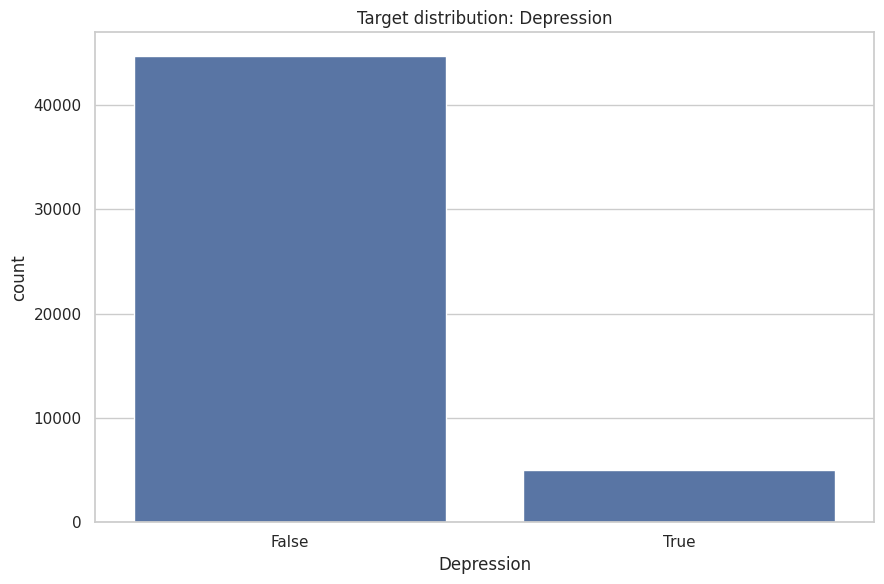

Numeric columns: ['Student_ID', 'Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']


,count,mean,std,min,25%,50%,75%,max
Student_ID,49784.0,25892.500000,14371.547238,1001.00,13446.75,25892.5,38338.25,50784.0
Age,49784.0,21.002109,1.999954,18.00,19.00,21.0,23.00,24.0
CGPA,49784.0,2.898195,0.532567,1.59,2.45,2.9,3.35,4.0
Sleep_Duration,49784.0,6.996268,1.505165,3.00,6.00,7.0,8.00,12.0
Study_Hours,49784.0,4.504246,1.977472,0.00,3.10,4.5,5.80,12.6
Social_Media_Hours,49784.0,3.505385,1.488222,0.00,2.50,3.5,4.50,10.0
Physical_Activity,49784.0,74.186506,43.365876,0.00,37.00,74.0,112.00,149.0
Stress_Level,49784.0,4.144464,1.419367,2.00,3.00,4.0,5.00,10.0


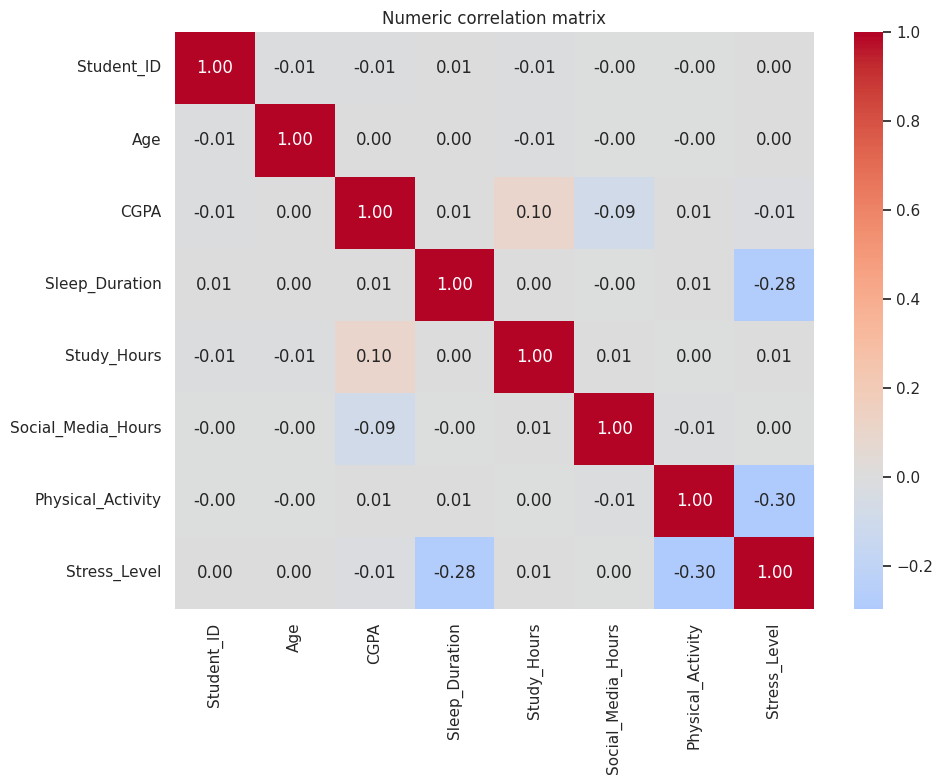

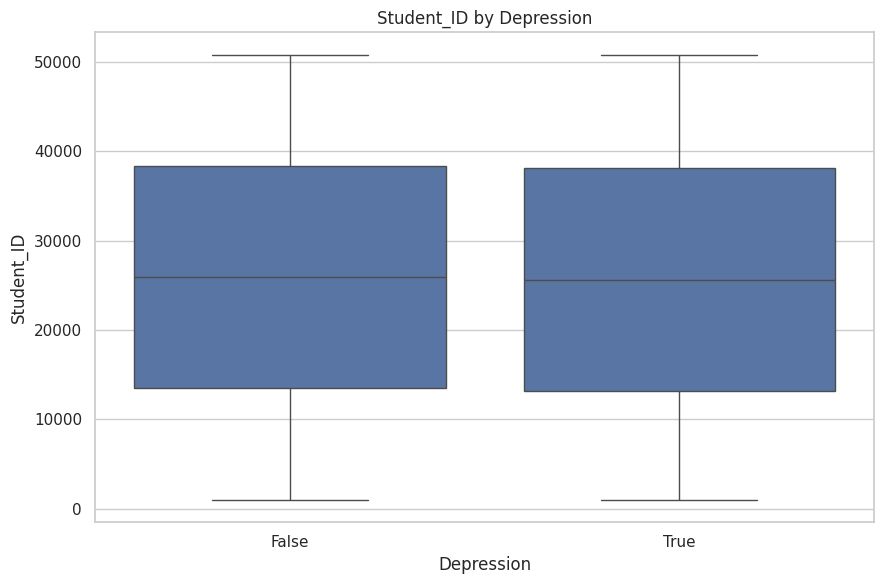

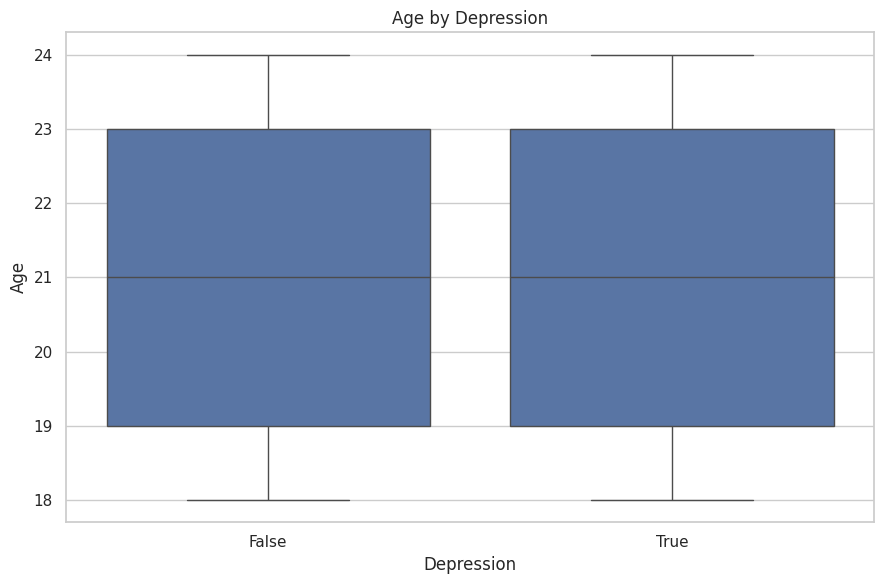

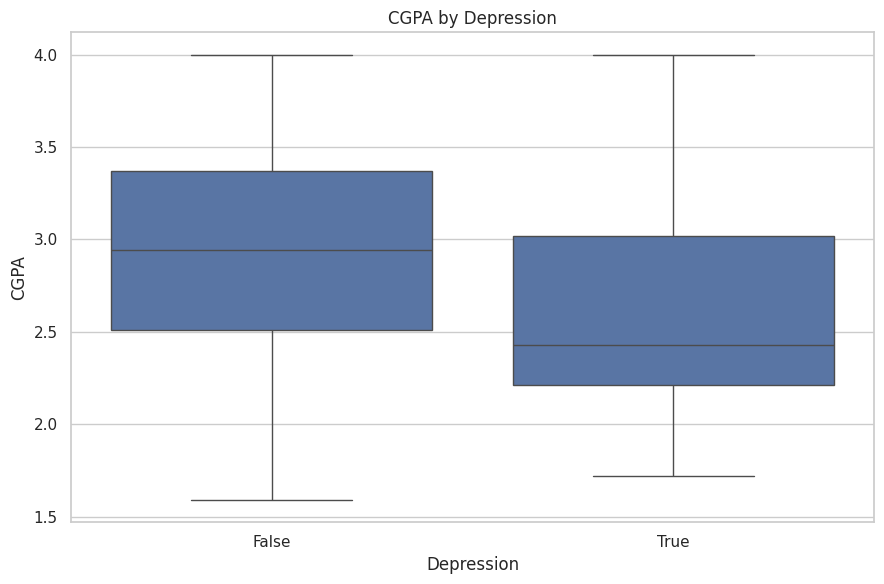

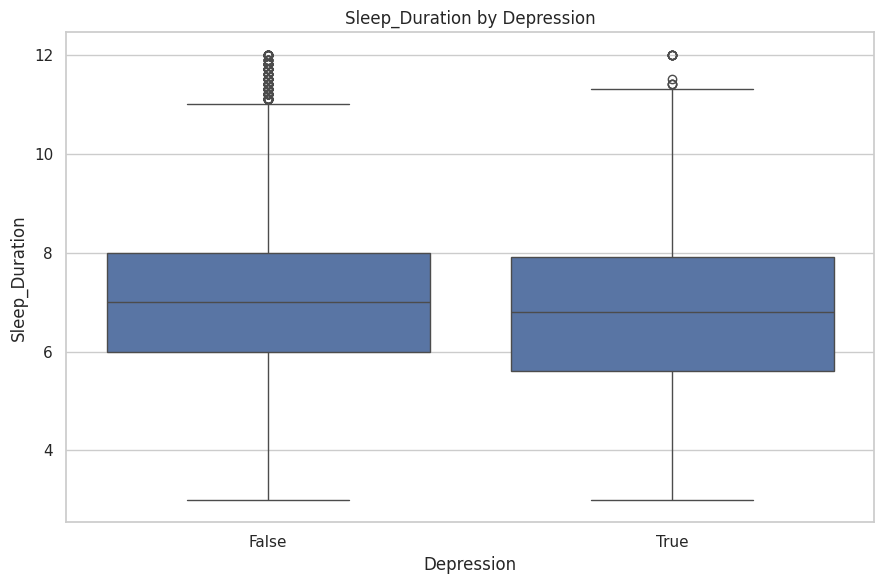

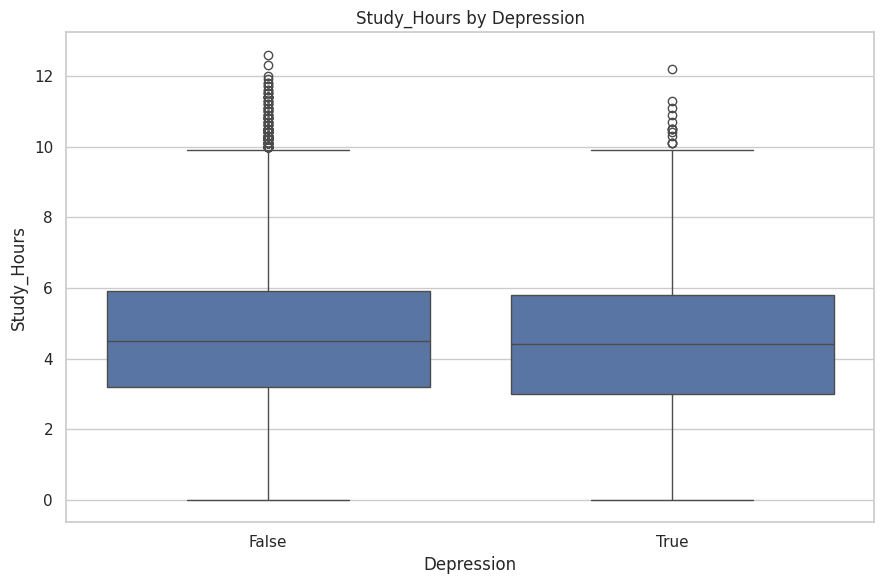

In [ ]:
# EDA (Missing Values & Target Distribution)
print("Missing values per column:")
display(df.isnull().sum().sort_values(ascending=False).head(50))

# Target distribution
plt.figure()
sns.countplot(x=target_col, data=df)
plt.title(f"Target distribution: {target_col}")
plt.tight_layout()
plt.show()

# Numeric summaries
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns:", numeric_cols)
display(df[numeric_cols].describe().T)

# Correlation heatmap (numeric only)
if len(numeric_cols) > 1:
    plt.figure(figsize=(10,8))
    sns.heatmap(df[numeric_cols].corr(), center=0, cmap='coolwarm', annot=True, fmt=".2f")
    plt.title("Numeric correlation matrix")
    plt.tight_layout()
    plt.show()

# Boxplots for key numeric features against target (first 5 numeric features)
for col in numeric_cols[:5]:
    plt.figure()
    sns.boxplot(x=target_col, y=col, data=df)
    plt.title(f"{col} by {target_col}")
    plt.tight_layout()
    plt.show()


In [ ]:
# Data Cleaning & Preparing Features (X) and Target (y)
# Drop obvious ID column if present
id_cols = ['Student_ID', 'student_id', 'ID', 'Id']
for ic in id_cols:
    if ic in df.columns:
        print("Dropping ID column:", ic)
        df = df.drop(columns=[ic])
        break

# Drop duplicates
n_dup = df.duplicated().sum()
if n_dup > 0:
    print("Dropping duplicates:", n_dup)
    df = df.drop_duplicates().reset_index(drop=True)

# Drop rows with missing target
n_target_nan = df[target_col].isnull().sum()
if n_target_nan > 0:
    print("Dropping rows with missing target:", n_target_nan)
    df = df.dropna(subset=[target_col]).reset_index(drop=True)

# Recompute X, y
X = df.drop(columns=[target_col]).copy()
y_raw = df[target_col].copy()

# Encode target: if text (Yes/No etc.) label-encode; if numeric with few unique values treat as classes
label_encoder = LabelEncoder()
if y_raw.dtype == 'object' or y_raw.dtype.name == 'category':
    y = label_encoder.fit_transform(y_raw)
    classes = list(label_encoder.classes_)
    print("Encoded target classes:", classes)
else:
    unique_vals = np.unique(y_raw)
    if len(unique_vals) <= 10 and np.all(np.equal(np.mod(unique_vals,1), 0)):
        # discrete integer-like classes
        y = y_raw.astype(int).values
        classes = list(np.unique(y))
        print("Numeric discrete classes detected:", classes)
    else:
        # numeric continuous -> bin into 3 classes (low/medium/high)
        print("Continuous target detected; binning into 3 classes (low/medium/high).")
        y_binned = pd.qcut(y_raw.rank(method='first'), 3, labels=["low", "medium", "high"])
        y = label_encoder.fit_transform(y_binned)
        classes = list(label_encoder.classes_)
        print("Binned classes:", classes)

print("Final dataset shape:", X.shape, "Labels shape:", y.shape)


Dropping ID column: Student_ID
Numeric discrete classes detected: [np.int64(0), np.int64(1)]
Final dataset shape: (49784, 9) Labels shape: (49784,)


In [ ]:
# Train-Test Split & Pipeline Setup
# Detect numeric and categorical features automatically
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object','category','bool']).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

# Fit preprocessor to compute transformed feature names
preprocessor.fit(X)
# build transformed feature names list
transformed_names = numeric_features.copy()
if categorical_features:
    ohe = preprocessor.named_transformers_['cat'].named_steps['ohe']
    cat_names = list(ohe.get_feature_names_out(categorical_features))
    transformed_names += cat_names
print("Transformed feature count:", len(transformed_names))


Numeric features: ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']
Categorical features: ['Gender', 'Department']
Transformed feature count: 14


In [ ]:
# Train Baseline Models (Logistic Regression & Random Forest)
from collections import Counter
counter = Counter(y)
print("Class counts:", counter)
counts = np.array(list(counter.values()))
imbalance_ratio = counts.max() / counts.min() if counts.min() > 0 else np.inf
print("Imbalance ratio (max/min):", round(imbalance_ratio,2))

use_smote = False
if imbalance_ratio > 4 or any(counts < 0.1 * len(y)):
    use_smote = True
    print("Using SMOTE during training.")
else:
    print("SMOTE not necessary.")


Class counts: Counter({np.int64(0): 44755, np.int64(1): 5029})
Imbalance ratio (max/min): 8.9
Using SMOTE during training.


In [ ]:
#stratified split and baseline models
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print("Train/test shapes:", X_train.shape, X_test.shape)

# Pipelines: include SMOTE in training pipeline if flagged
if use_smote:
    log_pipe = ImbPipeline(steps=[('pre', preprocessor), ('smote', SMOTE(random_state=42)), ('clf', LogisticRegression(max_iter=1000))])
    rf_pipe = ImbPipeline(steps=[('pre', preprocessor), ('smote', SMOTE(random_state=42)), ('clf', RandomForestClassifier(random_state=42))])
else:
    log_pipe = Pipeline(steps=[('pre', preprocessor), ('clf', LogisticRegression(max_iter=1000))])
    rf_pipe = Pipeline(steps=[('pre', preprocessor), ('clf', RandomForestClassifier(random_state=42))])

# Fit baselines
log_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)

def eval_clf(y_true, y_pred, avg='weighted'):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average=avg, zero_division=0),
        'recall': recall_score(y_true, y_pred, average=avg, zero_division=0),
        'f1': f1_score(y_true, y_pred, average=avg, zero_division=0)
    }

y_pred_log = log_pipe.predict(X_test)
y_pred_rf = rf_pipe.predict(X_test)

print("Logistic baseline:", eval_clf(y_test, y_pred_log))
print("RandomForest baseline:", eval_clf(y_test, y_pred_rf))


Train/test shapes: (39827, 9) (9957, 9)
Logistic baseline: {'accuracy': 0.6261926283016973, 'precision': 0.8679770875026149, 'recall': 0.6261926283016973, 'f1': 0.7003940735301267}
RandomForest baseline: {'accuracy': 0.8772722707642864, 'precision': 0.8461837315973222, 'recall': 0.8772722707642864, 'f1': 0.8587486819220068}


In [ ]:
#hyperparameter tuning (stratified CV)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic grid (note: if using ImbPipeline names will be 'clf__param')
param_grid_log = {
    'clf__C': [0.01, 0.1, 1, 10]
}
gs_log = GridSearchCV(log_pipe, param_grid_log, cv=cv, scoring='f1_weighted', n_jobs=-1)
print("Tuning Logistic Regression...")
gs_log.fit(X_train, y_train)
print("Best logistic params:", gs_log.best_params_, "Best CV f1:", gs_log.best_score_)

# RandomForest grid
param_grid_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [None, 8, 16],
    'clf__min_samples_split': [2, 5]
}
gs_rf = GridSearchCV(rf_pipe, param_grid_rf, cv=cv, scoring='f1_weighted', n_jobs=-1)
print("Tuning RandomForest (may take longer)...")
gs_rf.fit(X_train, y_train)
print("Best RF params:", gs_rf.best_params_, "Best CV f1:", gs_rf.best_score_)


Tuning Logistic Regression...
Best logistic params: {'clf__C': 10} Best CV f1: 0.6967869954959255
Tuning RandomForest (may take longer)...
Best RF params: {'clf__max_depth': None, 'clf__min_samples_split': 2, 'clf__n_estimators': 200} Best CV f1: 0.8546746802579094


In [ ]:

# Transform training and test sets
X_train_trans = preprocessor.transform(X_train)
X_test_trans = preprocessor.transform(X_test)
if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()
    X_test_trans = X_test_trans.toarray()

# (A) SelectKBest using ANOVA (f_classif)
k = min(12, X_train_trans.shape[1])
skb = SelectKBest(score_func=f_classif, k=k)
skb.fit(X_train_trans, y_train)
top_idx = np.argsort(skb.scores_)[-k:][::-1]
top_features = [transformed_names[i] for i in top_idx]
print("SelectKBest top features:", top_features)

# (B) Embedded selection with RF on full transformed train data
rf_emb = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_emb.fit(X_train_trans, y_train)
sfm = SelectFromModel(rf_emb, threshold='median')  # keep features above median importance
sfm.fit(X_train_trans, y_train)
sfm_features = [name for name, keep in zip(transformed_names, sfm.get_support()) if keep]
print("Embedded RF features:", sfm_features)

# Intersection (robust choice)
selected_features = [f for f in top_features if f in sfm_features]
if not selected_features:
    selected_features = top_features
print("Final selected features:", selected_features)

selected_indices = [transformed_names.index(f) for f in selected_features]
X_train_sel = X_train_trans[:, selected_indices]
X_test_sel = X_test_trans[:, selected_indices]
print("Selected matrices shape:", X_train_sel.shape, X_test_sel.shape)


SelectKBest top features: ['CGPA', 'Stress_Level', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Age', 'Department_Arts', 'Department_Medical', 'Department_Science', 'Department_Business', 'Department_Engineering']
Embedded RF features: ['Age', 'CGPA', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Stress_Level']
Final selected features: ['CGPA', 'Stress_Level', 'Sleep_Duration', 'Study_Hours', 'Social_Media_Hours', 'Physical_Activity', 'Age']
Selected matrices shape: (39827, 7) (9957, 7)


In [ ]:

# Extract best hyperparams from GridSearch results
best_log_params = gs_log.best_params_
best_rf_params = gs_rf.best_params_

# Convert keys like 'clf__C' -> 'C'
log_params_clean = {k.split('__')[-1]: v for k,v in best_log_params.items()}
rf_params_clean = {k.split('__')[-1]: v for k,v in best_rf_params.items()}

# Final Logistic
final_log = LogisticRegression(**log_params_clean, max_iter=2000, random_state=42)
final_log.fit(X_train_sel, y_train)
y_pred_log_final = final_log.predict(X_test_sel)
print("Final Logistic:", eval_clf(y_test, y_pred_log_final))

# Final RandomForest
final_rf = RandomForestClassifier(random_state=42, **rf_params_clean)
final_rf.fit(X_train_sel, y_train)
y_pred_rf_final = final_rf.predict(X_test_sel)
print("Final RandomForest:", eval_clf(y_test, y_pred_rf_final))

# Reports
print("\nClassification report - RandomForest (final):\n", classification_report(y_test, y_pred_rf_final, zero_division=0))
cm = confusion_matrix(y_test, y_pred_rf_final)
print("Confusion matrix (rows=true, cols=pred):\n", cm)


Final Logistic: {'accuracy': 0.8989655518730542, 'precision': 0.8081390634544248, 'recall': 0.8989655518730542, 'f1': 0.8511360963418351}
Final RandomForest: {'accuracy': 0.8994677111579793, 'precision': 0.8670472233415369, 'recall': 0.8994677111579793, 'f1': 0.8553490063790119}

Classification report - RandomForest (final):
               precision    recall  f1-score   support

           0       0.90      1.00      0.95      8951
           1       0.57      0.02      0.04      1006

    accuracy                           0.90      9957
   macro avg       0.73      0.51      0.49      9957
weighted avg       0.87      0.90      0.86      9957

Confusion matrix (rows=true, cols=pred):
 [[8935   16]
 [ 985   21]]


Num classes: 2


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,658 (10.38 KB)

 Trainable params: 2,658 (10.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8903 - loss: 0.3465 - val_accuracy: 0.9016 - val_loss: 0.3051
Epoch 2/100
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8976 - loss: 0.3148 - val_accuracy: 0.9011 - val_loss: 0.3019
Epoch 3/100
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8977 - loss: 0.3095 - val_accuracy: 0.9016 - val_loss: 0.3000
Epoch 4/100
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9005 - loss: 0.3019 - val_accuracy: 0.9016 - val_loss: 0.2999
Epoch 5/100
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9000 - loss: 0.3012 - val_accuracy: 0.9016 - val_loss: 0.2986
Epoch 6/100
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8968 - loss: 0.3065 - val_accuracy: 0.9016 - val_loss: 0.2978
Epoch 7/100
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8989 - loss: 0.3034 - val_accuracy: 0.9023 - val_loss: 0.2970
Epoch 8/100
1058/1058 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8989 - loss: 0

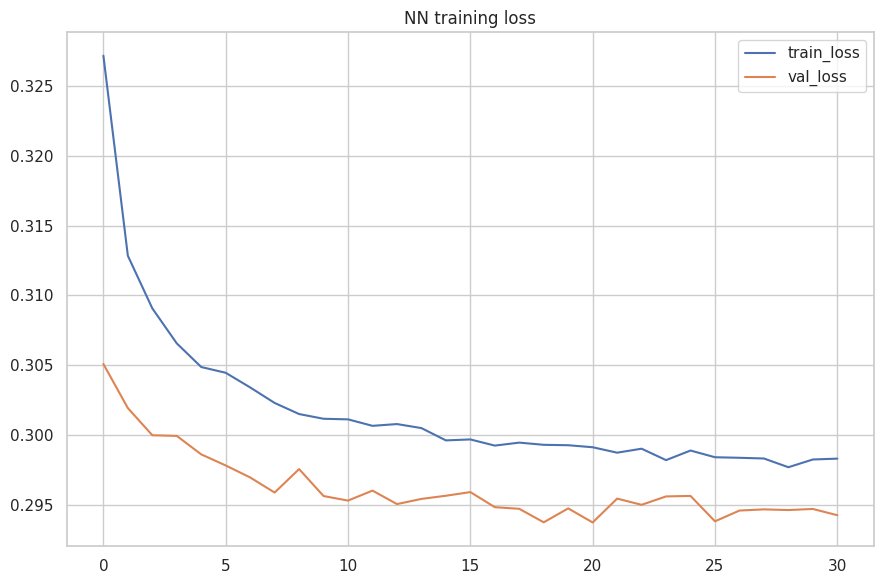

In [ ]:

scaler_sel = StandardScaler()
X_train_nn = scaler_sel.fit_transform(X_train_sel)
X_test_nn = scaler_sel.transform(X_test_sel)

num_classes = len(np.unique(y))
print("Num classes:", num_classes)

nn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])
nn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
nn.summary()

es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
history = nn.fit(X_train_nn, y_train, validation_split=0.15, epochs=100, batch_size=32, callbacks=[es], verbose=1)

# Evaluate
y_prob_nn = nn.predict(X_test_nn)
y_pred_nn = np.argmax(y_prob_nn, axis=1)
print("NN metrics:", eval_clf(y_test, y_pred_nn))
print("\nNN classification report:\n", classification_report(y_test, y_pred_nn, zero_division=0))

# Plot training loss
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("NN training loss")
plt.tight_layout()
plt.show()


In [ ]:

# Feature importance from final_rf
feat_imp = pd.Series(final_rf.feature_importances_, index=selected_features).sort_values(ascending=False)
print("RandomForest importances:")
display(feat_imp)

# Permutation importance (may take some time)
from sklearn.inspection import permutation_importance
perm = permutation_importance(final_rf, X_test_sel, y_test, n_repeats=20, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=selected_features).sort_values(ascending=False)
print("Permutation importances (mean):")
display(perm_imp)

# Save models and artifacts
joblib.dump(final_rf, "final_rf_classifier.joblib")
joblib.dump(final_log, "final_logistic_classifier.joblib")
joblib.dump(scaler_sel, "scaler_selected_features.joblib")
nn.save("final_nn_classifier.keras")

summary = {
    "dataset_path": DATA_PATH,
    "rows": int(df.shape[0]),
    "columns": int(df.shape[1]),
    "target": target_col,
    "classes": int(num_classes),
    "selected_features": selected_features,
    "rf_final_metrics": eval_clf(y_test, y_pred_rf_final),
    "log_final_metrics": eval_clf(y_test, y_pred_log_final),
    "nn_metrics": eval_clf(y_test, y_pred_nn),
    "rf_best_params": gs_rf.best_params_,
    "log_best_params": gs_log.best_params_,
    "saved_at_utc": datetime.utcnow().isoformat()
}
with open("project_summary_classification.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved models and summary JSON.")
display(pd.DataFrame([summary['rf_final_metrics'], summary['log_final_metrics'], summary['nn_metrics']],
                     index=['RF_final','Logistic_final','NN_final']))


RandomForest importances:


,0
CGPA,0.216824
Physical_Activity,0.173103
Study_Hours,0.158099
Sleep_Duration,0.154452
Social_Media_Hours,0.149049
Age,0.075026
Stress_Level,0.073447


Permutation importances (mean):


,0
Stress_Level,0.001351
CGPA,0.001215
Study_Hours,0.000884
Sleep_Duration,0.000653
Social_Media_Hours,0.000306
Age,0.000171
Physical_Activity,0.000131


Saved models and summary JSON.


,accuracy,precision,recall,f1
RF_final,0.899468,0.867047,0.899468,0.855349
Logistic_final,0.898966,0.808139,0.898966,0.851136
NN_final,0.898263,0.843795,0.898263,0.852316
